# DAL Assignment 7
### Submitted by: Harshil Pandey (DA24C006)

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay, classification_report

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import seaborn as sns
sns.set_theme()

The results are vizualized and interpreted in the last section.

# Task 1

### Loading the Dataset and Some EDA

In [4]:
train_data=pd.read_csv('aps_failure_training_set.csv', header=14, na_values='na')
train_data.head()
X, y=train_data.drop('class', axis=1), train_data['class']
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

Some of the features have high percentage of null values, those features are identified below.

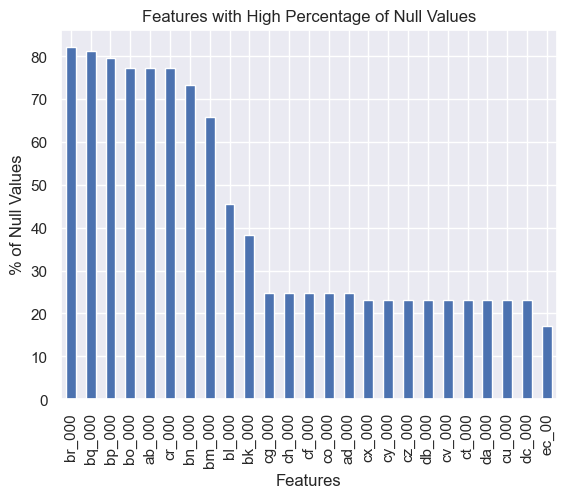

In [128]:
ax=(X.isnull().sum()*100/X.shape[0]).sort_values(ascending=False)[:25].plot.bar()
ax.set_xlabel('Features')
ax.set_ylabel('% of Null Values')
ax.set_title('Features with High Percentage of Null Values');

Some features have very low standard deviations. But that may also be due to the different scales of the features. 

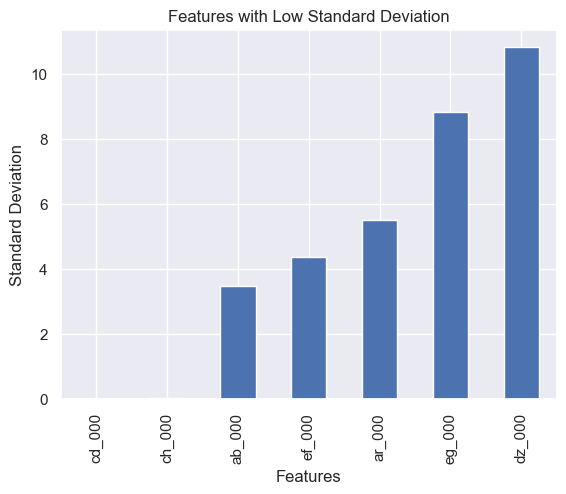

In [135]:
ax=(X.describe().loc['std'].sort_values()[:7]).plot.bar()
ax.set_xlabel('Features')
ax.set_ylabel('Standard Deviation')
ax.set_title('Features with Low Standard Deviation');

All this suggests, that the dataset needs some level of cleaning. For that, I have imputed the null values using median strategy. On top of that, I have scaled each feature using `StandardScaler`.

In [7]:
preprocess=Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                           ('scaler', StandardScaler())])
preprocess.fit(X_train, X_test)
X_train=preprocess.transform(X_train)
X_test=preprocess.transform(X_test)

Due to high fitting times of `SVM` and redundancy in the Dataset, I have used `PCA` as the dimensionality reduction technique on the scaled dataset. The `PCA` output will only be used to train `SVM` as it greatly reduces the fitting and cross-validation time. Since `LogisticRegression` and `DecisionTree` have relatively lower fitting times, the whole scaled dataset will be used for training them.

In [8]:
pca=PCA(n_components=11)
pca.fit(X_train)

PCA(n_components=11)

In [8]:
X_train=pca.transform(X_train)
X_test=pca.transform(X_test)

This function outputs the model performance on both the training and test data

In [9]:
def model_report(model):
    print('Train Performance:')
    predictions=model.predict(X_train)
    print('\tF1 Score: %.3f'%f1_score(y_train, predictions, average='macro'))
    print('\tPrecision Score: %.3f'%precision_score(y_train, predictions, average='macro'))
    print('\tRecall Score: %.3f'%recall_score(y_train, predictions, average='macro'))
    print('\tAccuracy Score: %.3f'%accuracy_score(y_train, predictions))
    
    print('Test Performance:')
    predictions=model.predict(X_test)
    print('\tF1 Score: %.3f'%f1_score(y_test, predictions, average='macro'))
    print('\tPrecision Score: %.3f'%precision_score(y_test, predictions, average='macro'))
    print('\tRecall Score: %.3f'%recall_score(y_test, predictions, average='macro'))
    print('\tAccuracy Score: %.3f'%accuracy_score(y_test, predictions))


## Baseline Models

Best `Hyper-Parameters` are found using `Grid Seach` and the scoring for each fold is done using the `Macro F1` score

### SVC

In [58]:
gscv=GridSearchCV(estimator=SVC(), param_grid={'kernel': ['rbf', 'sigmoid'],
                                               'gamma': ['auto', 'scale']}, 
                  cv=4, scoring='f1_macro', n_jobs=-1, refit=False)
gscv.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=SVC(), n_jobs=-1,
             param_grid={'gamma': ['auto', 'scale'],
                         'kernel': ['rbf', 'sigmoid']},
             refit=False, scoring='f1_macro')

In [59]:
svc=SVC(**gscv.best_params_)
svc.fit(X_train, y_train)
model_report(svc)

Train Performance:
	F1 Score: 0.907
	Precision Score: 0.970
	Recall Score: 0.859
	Accuracy Score: 0.995
Test Performance:
	F1 Score: 0.812
	Precision Score: 0.888
	Recall Score: 0.761
	Accuracy Score: 0.990


### Logistic Regression

In [139]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)
X_train=preprocess.transform(X_train)
X_test=preprocess.transform(X_test)

In [140]:
log_reg=LogisticRegression(solver='liblinear')
gscv=GridSearchCV(estimator=log_reg, param_grid={'solver': ['liblinear'],
                                                 'penalty': ['l1', 'l2'],
                                                 'C': [0.01, 0.1, 0.25]},
                  cv=4, scoring='f1_macro', refit=False)
gscv.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=LogisticRegression(solver='liblinear'),
             param_grid={'C': [0.01, 0.1, 0.25], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             refit=False, scoring='f1_macro')

In [141]:
gscv.best_params_, gscv.best_score_

({'C': 0.25, 'penalty': 'l1', 'solver': 'liblinear'},
 np.float64(0.8520417704104845))

In [142]:
log_reg=LogisticRegression(**gscv.best_params_)
log_reg.fit(X_train, y_train)

LogisticRegression(C=0.25, penalty='l1', solver='liblinear')

In [143]:
model_report(log_reg)

Train Performance:
	F1 Score: 0.877
	Precision Score: 0.927
	Recall Score: 0.838
	Accuracy Score: 0.993
Test Performance:
	F1 Score: 0.835
	Precision Score: 0.890
	Recall Score: 0.794
	Accuracy Score: 0.991


### Decision Tree

In [14]:
dt=DecisionTreeClassifier()
gscv=GridSearchCV(estimator=dt, param_grid={'max_depth': [None, 25, 30],
                                            'min_samples_leaf': [1, 3]},
                  cv=4, scoring='f1_macro', refit=False, n_jobs=-1)
gscv.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [None, 25, 30],
                         'min_samples_leaf': [1, 3]},
             refit=False, scoring='f1_macro')

In [15]:
gscv.best_params_, gscv.best_score_

({'max_depth': 30, 'min_samples_leaf': 3}, np.float64(0.8396150375473983))

In [19]:
dt=DecisionTreeClassifier(**gscv.best_params_)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=30, min_samples_leaf=3)

In [20]:
model_report(dt)

Train Performance:
	F1 Score: 0.964
	Precision Score: 0.973
	Recall Score: 0.956
	Accuracy Score: 0.998
Test Performance:
	F1 Score: 0.841
	Precision Score: 0.856
	Recall Score: 0.828
	Accuracy Score: 0.990


# Task 2

## Oversampling
For Oversampling Strategy, the minority class (`pos`) will be sampled and synthetic data for that class will be created and added to the dataset before fitting a classifier. For oversampling strategy, I have used `SMOTE` which stands for Synthetic Minority Oversampling Technique. In this strategy, a point of minority class is selected and some (in our case, 5) nearest neighbors of that point also belonging to the minority class are selected. Then the average value of the features are taken from these calculated neighbor points and added to the dataset. Synthetic data points are generated until we meet a threshold proportion of minority class data points when compared to the majority class.

In all the cases below, `SMOTE` has been made the previous step before fitting the classifier on the datset using a `Pipeline`.

### Logistic Regression

In [20]:
log_reg_pipeline=Pipeline([('sampler', SMOTE(sampling_strategy=0.07)),
                           ('clsf', LogisticRegression(max_iter=500))])

gscv=GridSearchCV(estimator=log_reg_pipeline, param_grid={'clsf__solver': ['liblinear'],
                                                 'clsf__penalty': ['l1', 'l2'],
                                                 'clsf__C': [0.01, 0.1, 0.25]},
                  cv=4, scoring='f1_macro', refit=False)
gscv.fit(X_train, y_train)

GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('sampler',
                                        SMOTE(sampling_strategy=0.07)),
                                       ('clsf',
                                        LogisticRegression(max_iter=500))]),
             param_grid={'clsf__C': [0.01, 0.1, 0.25],
                         'clsf__penalty': ['l1', 'l2'],
                         'clsf__solver': ['liblinear']},
             refit=False, scoring='f1_macro')

In [21]:
gscv.best_params_, gscv.best_score_

({'clsf__C': 0.1, 'clsf__penalty': 'l1', 'clsf__solver': 'liblinear'},
 np.float64(0.8572393339995112))

In [22]:
log_reg_pipeline.set_params(**gscv.best_params_)
log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('sampler', SMOTE(sampling_strategy=0.07)),
                ('clsf',
                 LogisticRegression(C=0.1, max_iter=500, penalty='l1',
                                    solver='liblinear'))])

In [23]:
model_report(log_reg_pipeline)

Train Performance:
	F1 Score: 0.872
	Precision Score: 0.848
	Recall Score: 0.900
	Accuracy Score: 0.991
Test Performance:
	F1 Score: 0.843
	Precision Score: 0.827
	Recall Score: 0.862
	Accuracy Score: 0.989


### Descision Tree

In [23]:
dt_pipeline=Pipeline([('sampler', SMOTE(sampling_strategy=0.07)),
                      ('clsf', DecisionTreeClassifier())])

gscv=GridSearchCV(estimator=dt_pipeline, param_grid={'clsf__max_depth': [None, 15],
                                            'clsf__min_samples_leaf': [1, 3, 5]},
                  cv=4, scoring='f1_macro', refit=False, n_jobs=-1)
gscv.fit(X_train, y_train)

GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('sampler',
                                        SMOTE(sampling_strategy=0.07)),
                                       ('clsf', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'clsf__max_depth': [None, 15],
                         'clsf__min_samples_leaf': [1, 3, 5]},
             refit=False, scoring='f1_macro')

In [24]:
gscv.best_params_, gscv.best_score_

({'clsf__max_depth': 15, 'clsf__min_samples_leaf': 5},
 np.float64(0.8285381211672587))

In [25]:
dt_pipeline.set_params(**gscv.best_params_)
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('sampler', SMOTE(sampling_strategy=0.07)),
                ('clsf',
                 DecisionTreeClassifier(max_depth=15, min_samples_leaf=5))])

In [26]:
model_report(dt_pipeline)

Train Performance:
	F1 Score: 0.944
	Precision Score: 0.939
	Recall Score: 0.949
	Accuracy Score: 0.996
Test Performance:
	F1 Score: 0.849
	Precision Score: 0.852
	Recall Score: 0.845
	Accuracy Score: 0.990


### SVC

In [29]:
X_train=pca.transform(X_train)
X_test=pca.transform(X_test)

In [38]:
svc_pipeline=Pipeline([('sampler', SMOTE(sampling_strategy=0.07)),
                       ('clsf', SVC())])
gscv=GridSearchCV(svc_pipeline, param_grid={'clsf__kernel': ['rbf', 'sigmoid'],
                                            'clsf__gamma': ['auto', 'scale']},
                   cv=4, scoring='f1_macro', refit=False, n_jobs=-1)
gscv.fit(X_train, y_train)

GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('sampler',
                                        SMOTE(sampling_strategy=0.07)),
                                       ('clsf', SVC())]),
             n_jobs=-1,
             param_grid={'clsf__gamma': ['auto', 'scale'],
                         'clsf__kernel': ['rbf', 'sigmoid']},
             refit=False, scoring='f1_macro')

In [39]:
gscv.best_params_, gscv.best_score_

({'clsf__gamma': 'scale', 'clsf__kernel': 'rbf'},
 np.float64(0.8440678325735268))

In [40]:
svc_pipeline.set_params(**gscv.best_params_)
svc_pipeline.fit(X_train, y_train)

Pipeline(steps=[('sampler', SMOTE(sampling_strategy=0.07)), ('clsf', SVC())])

In [41]:
model_report(svc_pipeline)

Train Performance:
	F1 Score: 0.896
	Precision Score: 0.877
	Recall Score: 0.916
	Accuracy Score: 0.993
Test Performance:
	F1 Score: 0.834
	Precision Score: 0.822
	Recall Score: 0.847
	Accuracy Score: 0.989


## Class Weight
In this strategy, more weightage is given to the minority class for a prediction. The class weight is almost always inversely proportional to the number of data points of the class. Since there is a lack of data for the minority class, giving more weight to each minority class data point helps the model to recognize it better. This strategy improves the Recall Score for the minority class.

### Logistic Regression

In [47]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)
X_train=preprocess.transform(X_train)
X_test=preprocess.transform(X_test)

In [76]:
log_reg=LogisticRegression(solver='lbfgs', class_weight={'neg': 0.35, 'pos': 1},
                           max_iter=500)
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight={'neg': 0.35, 'pos': 1}, max_iter=500)

In [75]:
model_report(log_reg)

Train Performance:
	F1 Score: 0.882
	Precision Score: 0.872
	Recall Score: 0.893
	Accuracy Score: 0.992
Test Performance:
	F1 Score: 0.837
	Precision Score: 0.835
	Recall Score: 0.840
	Accuracy Score: 0.989


### Decision Tree

In [88]:
dt=DecisionTreeClassifier(class_weight={'neg': 0.40, 'pos': 1})
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={'neg': 0.4, 'pos': 1})

In [89]:
model_report(dt)

Train Performance:
	F1 Score: 1.000
	Precision Score: 1.000
	Recall Score: 1.000
	Accuracy Score: 1.000
Test Performance:
	F1 Score: 0.848
	Precision Score: 0.862
	Recall Score: 0.835
	Accuracy Score: 0.990


### SVC

In [90]:
X_train=pca.transform(X_train)
X_test=pca.transform(X_test)

In [103]:
svc=SVC(kernel='rbf', class_weight={'neg': 0.4, 'pos': 1})
svc.fit(X_train, y_train)

SVC(class_weight={'neg': 0.4, 'pos': 1})

In [104]:
model_report(svc)

Train Performance:
	F1 Score: 0.896
	Precision Score: 0.888
	Recall Score: 0.905
	Accuracy Score: 0.993
Test Performance:
	F1 Score: 0.830
	Precision Score: 0.820
	Recall Score: 0.839
	Accuracy Score: 0.989


## Combining All Methods
In this section, all methods discussed above are combined then a classifier is learnt. So `oversampling` is done, `classweight` is also supplied and then the best paremeters are found through `Grid Search`.

### Logistic Regression

In [105]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)
X_train=preprocess.transform(X_train)
X_test=preprocess.transform(X_test)

In [34]:
log_reg_pipeline=Pipeline([('sampler', SMOTE(sampling_strategy=0.07)),
                           ('clsf', LogisticRegression(max_iter=500, class_weight={'neg': 0.95, 'pos': 1}))])

gscv=GridSearchCV(log_reg_pipeline, param_grid={'clsf__max_iter': [500],
                                                'clsf__class_weight': [{'neg': 0.95, 'pos': 1}],
                                                'clsf__solver': ['liblinear'],
                                                'clsf__penalty': ['l1', 'l2'],
                                                'clsf__C': [0.01, 0.1, 0.25]},
                  cv=4, scoring='f1_macro', refit=True, n_jobs=-1)
gscv.fit(X_train, y_train)

GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('sampler',
                                        SMOTE(sampling_strategy=0.07)),
                                       ('clsf',
                                        LogisticRegression(class_weight={'neg': 0.95,
                                                                         'pos': 1},
                                                           max_iter=500))]),
             n_jobs=-1,
             param_grid={'clsf__C': [0.01, 0.1, 0.25],
                         'clsf__class_weight': [{'neg': 0.95, 'pos': 1}],
                         'clsf__max_iter': [500], 'clsf__penalty': ['l1', 'l2'],
                         'clsf__solver': ['liblinear']},
             scoring='f1_macro')

In [35]:
gscv.best_params_, gscv.best_score_

({'clsf__C': 0.25,
  'clsf__class_weight': {'neg': 0.95, 'pos': 1},
  'clsf__max_iter': 500,
  'clsf__penalty': 'l2',
  'clsf__solver': 'liblinear'},
 np.float64(0.8528716563998056))

In [36]:
log_reg_pipeline.set_params(**gscv.best_params_)
log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('sampler', SMOTE(sampling_strategy=0.07)),
                ('clsf',
                 LogisticRegression(C=0.25,
                                    class_weight={'neg': 0.95, 'pos': 1},
                                    max_iter=500, solver='liblinear'))])

In [37]:
model_report(log_reg_pipeline)

Train Performance:
	F1 Score: 0.873
	Precision Score: 0.849
	Recall Score: 0.900
	Accuracy Score: 0.991
Test Performance:
	F1 Score: 0.846
	Precision Score: 0.828
	Recall Score: 0.867
	Accuracy Score: 0.989


### Decision Tree

In [16]:
dt_pipeline=Pipeline([('sampler', SMOTE(sampling_strategy=0.03)),
                      ('clsf', DecisionTreeClassifier())])

gscv=GridSearchCV(estimator=dt_pipeline, param_grid={'clsf__max_depth': [None, 15],
                                            'clsf__min_samples_leaf': [1, 3, 5],
                                            'clsf__class_weight': [{'neg': 1, 'pos': 1}]},
                  cv=4, scoring='f1_macro', refit=False, n_jobs=-1)
gscv.fit(X_train, y_train)

GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('sampler',
                                        SMOTE(sampling_strategy=0.03)),
                                       ('clsf', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'clsf__class_weight': [{'neg': 1, 'pos': 1}],
                         'clsf__max_depth': [None, 15],
                         'clsf__min_samples_leaf': [1, 3, 5]},
             refit=False, scoring='f1_macro')

In [17]:
gscv.best_params_, gscv.best_score_

({'clsf__class_weight': {'neg': 1, 'pos': 1},
  'clsf__max_depth': 15,
  'clsf__min_samples_leaf': 1},
 np.float64(0.8436232111341264))

In [18]:
dt_pipeline.set_params(**gscv.best_params_)
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('sampler', SMOTE(sampling_strategy=0.03)),
                ('clsf',
                 DecisionTreeClassifier(class_weight={'neg': 1, 'pos': 1},
                                        max_depth=15))])

In [19]:
model_report(dt_pipeline)

Train Performance:
	F1 Score: 0.988
	Precision Score: 1.000
	Recall Score: 0.978
	Accuracy Score: 0.999
Test Performance:
	F1 Score: 0.845
	Precision Score: 0.848
	Recall Score: 0.843
	Accuracy Score: 0.990


### SVC

In [20]:
X_train=pca.transform(X_train)
X_test=pca.transform(X_test)

In [45]:
svc_pipeline=Pipeline([('sampler', SMOTE(sampling_strategy=0.04)),
                       ('clsf', SVC())])
gscv=GridSearchCV(svc_pipeline, param_grid={'clsf__kernel': ['rbf', 'sigmoid'],
                                            'clsf__gamma': ['auto', 'scale'],
                                            'clsf__class_weight': [{'neg': 0.7, 'pos': 1}]},
                   cv=4, scoring='f1_macro', refit=False, n_jobs=-1)
gscv.fit(X_train, y_train)

GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('sampler',
                                        SMOTE(sampling_strategy=0.04)),
                                       ('clsf', SVC())]),
             n_jobs=-1,
             param_grid={'clsf__class_weight': [{'neg': 0.7, 'pos': 1}],
                         'clsf__gamma': ['auto', 'scale'],
                         'clsf__kernel': ['rbf', 'sigmoid']},
             refit=False, scoring='f1_macro')

In [46]:
gscv.best_params_, gscv.best_score_

({'clsf__class_weight': {'neg': 0.7, 'pos': 1},
  'clsf__gamma': 'scale',
  'clsf__kernel': 'rbf'},
 np.float64(0.8439520237127871))

In [47]:
svc_pipeline.set_params(**gscv.best_params_)
svc_pipeline.fit(X_train, y_train)

Pipeline(steps=[('sampler', SMOTE(sampling_strategy=0.04)),
                ('clsf', SVC(class_weight={'neg': 0.7, 'pos': 1}))])

In [48]:
model_report(svc_pipeline)

Train Performance:
	F1 Score: 0.897
	Precision Score: 0.878
	Recall Score: 0.918
	Accuracy Score: 0.993
Test Performance:
	F1 Score: 0.834
	Precision Score: 0.819
	Recall Score: 0.849
	Accuracy Score: 0.989


## Results

In [51]:
results=pd.DataFrame(index=['Logistic Regression', 'Decision Tree', 'SVM'],
                     columns=['Baseline', 'Oversampling', 'Class Weight', 'Combined'])
results.loc['Logistic Regression', 'Baseline']=0.835
results.loc['Logistic Regression', 'Oversampling']=0.843
results.loc['Logistic Regression', 'Class Weight']=0.837
results.loc['Logistic Regression', 'Combined']=0.846

results.loc['Decision Tree', 'Baseline']=0.841
results.loc['Decision Tree', 'Oversampling']=0.849
results.loc['Decision Tree', 'Class Weight']=0.848
results.loc['Decision Tree', 'Combined']=0.845

results.loc['SVM', 'Baseline']=0.812
results.loc['SVM', 'Oversampling']=0.834
results.loc['SVM', 'Class Weight']=0.83
results.loc['SVM', 'Combined']=0.834

results

,Baseline,Oversampling,Class Weight,Combined
Logistic Regression,0.835,0.843,0.837,0.846
Decision Tree,0.841,0.849,0.848,0.845
SVM,0.812,0.834,0.83,0.834


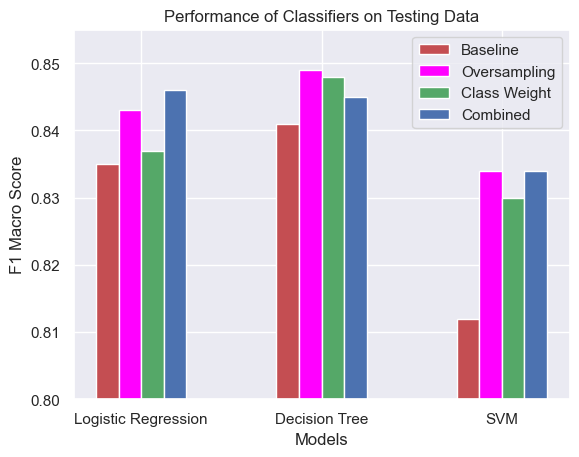

In [144]:
width=0.125
x=np.arange(3)
ax=plt.axes()
ax.bar(x-2*width, results['Baseline'], width, color='r', align='edge', label='Baseline')
ax.bar(x-width, results['Oversampling'], width, color='magenta', align='edge', label='Oversampling')
ax.bar(x, results['Class Weight'], width, color='g', align='edge', label='Class Weight')
ax.bar(x+width, results['Combined'], width, color='b', align='edge', label='Combined')

ax.set_xticks(x)
ax.set_xticklabels(results.index)
ax.set_ylim(bottom=0.8, top=0.855)

ax.set_ylabel('F1 Macro Score')
ax.set_xlabel('Models')
ax.set_title('Performance of Classifiers on Testing Data')

plt.legend();

We can easily observe that for all the models, the hacked classifiers have better performance on Testing data when compared to the baseline models. 
* For `LogisticRegression` the best classifier was the one in which all methods were combined. `Class Weight` does not seem to be an effective strategy for `LogisticRegression`
* `Oversampling` was the most effective startegy for `Decision Tree` and combining all the methods was the least effective.
* All strategies give a significant improvement to `SVM`, this may be because `SVM` is supplied with the least amount of data and even a little help by manipulating improves its performance. `Oversampling` performs the best while `Class Weight` was the least effective.